In [2]:
!pip install scikit-learn==1.5.2

In [ ]:
!pip install xgboost==1.7.2

Class Distribution Before SMOTE:
 Fertilizer
3    11
2     5
0     4
1     2
Name: count, dtype: int64
Class Distribution After SMOTE:
 Fertilizer
0    11
1    11
3    11
2    11
Name: count, dtype: int64
[0]	validation_0-mlogloss:1.36440	validation_1-mlogloss:1.37060
[1]	validation_0-mlogloss:1.34648	validation_1-mlogloss:1.35494
[2]	validation_0-mlogloss:1.33245	validation_1-mlogloss:1.34184
[3]	validation_0-mlogloss:1.32022	validation_1-mlogloss:1.32924
[4]	validation_0-mlogloss:1.29791	validation_1-mlogloss:1.31694
[5]	validation_0-mlogloss:1.28623	validation_1-mlogloss:1.30403
[6]	validation_0-mlogloss:1.27002	validation_1-mlogloss:1.29309


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:861: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[7]	validation_0-mlogloss:1.25547	validation_1-mlogloss:1.28175
[8]	validation_0-mlogloss:1.24842	validation_1-mlogloss:1.27712
[9]	validation_0-mlogloss:1.22906	validation_1-mlogloss:1.26076
[10]	validation_0-mlogloss:1.21257	validation_1-mlogloss:1.24421
[11]	validation_0-mlogloss:1.19025	validation_1-mlogloss:1.22291
[12]	validation_0-mlogloss:1.16833	validation_1-mlogloss:1.20204
[13]	validation_0-mlogloss:1.16140	validation_1-mlogloss:1.19603
[14]	validation_0-mlogloss:1.14629	validation_1-mlogloss:1.18014
[15]	validation_0-mlogloss:1.13223	validation_1-mlogloss:1.16756
[16]	validation_0-mlogloss:1.11919	validation_1-mlogloss:1.15910
[17]	validation_0-mlogloss:1.10924	validation_1-mlogloss:1.14923
[18]	validation_0-mlogloss:1.09832	validation_1-mlogloss:1.14016
[19]	validation_0-mlogloss:1.09085	validation_1-mlogloss:1.13235
[20]	validation_0-mlogloss:1.07591	validation_1-mlogloss:1.11914
[21]	validation_0-mlogloss:1.06969	validation_1-mlogloss:1.11178
[22]	validation_0-mlogloss:1

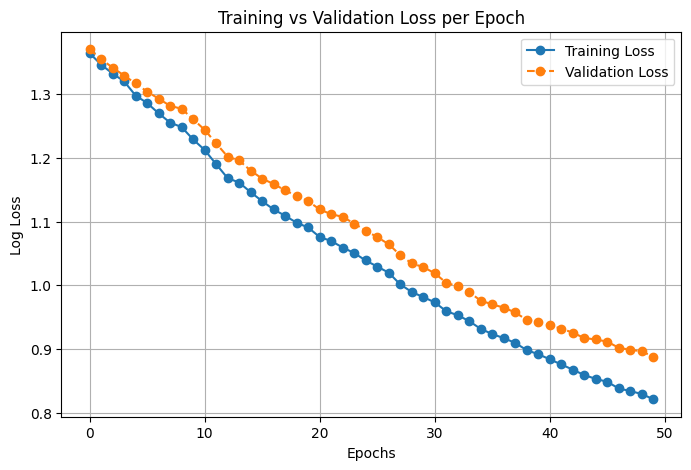

In [25]:
# Import required libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
file_path = "labeled_fertilizer_data.csv"  # Ensure correct path
data = pd.read_csv(file_path)

# Handle missing values
data.fillna(data.mean(numeric_only=True), inplace=True)

# Encode categorical variables
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Split Features and Target
target_column = "Fertilizer"  # Ensure this is correct
X = data.drop(target_column, axis=1)
y = data[target_column]

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Check class distribution before SMOTE
print("Class Distribution Before SMOTE:\n", pd.Series(y).value_counts())

# Apply SMOTE (Custom Sampling Strategy to Avoid Over-Oversampling)
smote = SMOTE(random_state=42, k_neighbors=1, sampling_strategy='not majority')  # Only oversamples minority classes
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check class distribution after SMOTE
print("Class Distribution After SMOTE:\n", pd.Series(y_resampled).value_counts())

# Stratified split to prevent class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Reduce Overfitting in XGBoost (Set early_stopping_rounds properly)
xgb_model = XGBClassifier(
    n_estimators=50,  # Reduced from 70
    max_depth=3,  # Shallower trees
    learning_rate=0.05,
    subsample=0.7,  # Less chance of memorization
    colsample_bytree=0.7,
    reg_alpha=2,  # Stronger L1 regularization
    reg_lambda=3,  # Stronger L2 regularization
    random_state=42,
    eval_metric="mlogloss"
)

# Ensure evaluation set is defined properly for early stopping
eval_set = [(X_train, y_train), (X_test, y_test)]  # Proper eval_set with both train and test

# Train XGBoost with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=eval_set,  # Proper eval_set with train and test data
    early_stopping_rounds=5,  # Early stopping
    verbose=True  # Print training progress
)

# Reduce Overfitting in Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50,  # Reduced from 80
    max_depth=5,  # Shallower depth
    random_state=42
)
rf_model.fit(X_train, y_train)

# Voting Ensemble (RF + XGB)
voting_model = VotingClassifier(estimators=[
    ('Random Forest', rf_model),
    ('XGBoost', xgb_model)
], voting='soft')
voting_model.fit(X_train, y_train)

# Save the ensemble model
with open("fertilizer_ensemble_model.pkl", "wb") as file:
    pickle.dump(voting_model, file)

# Evaluate the Voting Classifier
y_pred = voting_model.predict(X_test)

# Accuracy Calculation
sample_probabilities = probabilities[0]

sorted_indices = np.argsort(sample_probabilities)[::-1]
sorted_probabilities = sample_probabilities[sorted_indices]
sorted_classes = label_encoder.inverse_transform(sorted_indices)

for label, prob in zip(sorted_classes, sorted_probabilities):
    print(f"Class: {label}, Probability: {prob:.4f}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Cross-Validation Score (to verify generalization)
cv_score = cross_val_score(voting_model, X_resampled, y_resampled, cv=5)
print("\Validation Accuracy: ", np.mean(cv_score))

# Extract accuracy per epoch for XGBoost
epochs = len(xgb_model.evals_result()['validation_0']['mlogloss'])
train_errors = xgb_model.evals_result()['validation_0']['mlogloss']
test_errors = xgb_model.evals_result()['validation_1']['mlogloss']

# Plot Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), train_errors, label='Training Loss', marker='o')
plt.plot(range(epochs), test_errors, label='Validation Loss', marker='o', linestyle='dashed')
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.title("Training vs Validation Loss per Epoch")
plt.legend()
plt.grid()
plt.show()